In [1]:
import matplotlib.pyplot as plt
from neo4j import GraphDatabase
import re
import functools

URI = "bolt://localhost:7687"
AUTH = ("neo4j", "password")

In [15]:
#################### decorator for using neo4j ###################

def _uses_db(func):
    @functools.wraps(func)
    def connexion_manager(*args, **kwargs):
        with GraphDatabase.driver(uri=URI, auth=AUTH) as driver:
            driver.verify_connectivity()
            with driver.session(database=AUTH[0]) as session:
                return func(*args, session = session, **kwargs)

    return connexion_manager

################### functions to retrieve data from neo4j ##################

@_uses_db
def query_all_specs(session = None):
    members = []
    query = """match (root:SpecificationNode) where not (root)<-[:CONTAINS]-()
return 'root' as name, root.type AS type, 'root' as path, elementId(root) AS id
UNION
match (root:SpecificationNode) where not (root)<-[:CONTAINS]-()
match p=(root)-[:CONTAINS*]->(s:SpecificationNode)
with reduce(occ="root", n in nodes(p)[1..]|occ+'.'+n.name) as path, s as spec
return spec.name AS name, spec.type AS type, path, elementId(spec) AS id order by path"""
    result = session.run(query)
    for n, t, p, uri in result:
        members.append({'name': n, 'type': t, 'path': p, 'id': uri})
    #db_id = re.match(".*:.*:", members[0]['id']).group()
    
    return members#, db_id

def path_ids_map_of_valuenodes(element_ids, session):
    query = f"""MATCH (vn:ValueNode) WHERE elementId(vn) IN {str(element_ids)}
MATCH (root:SpecificationNode) WHERE NOT (root)<-[:CONTAINS]-()
MATCH p=(root)-[:CONTAINS*]->(s:SpecificationNode)<-[:IS_SPECIFIED_BY]-(vn)
WITH vn, reduce(occ="root", n in nodes(p)[1..-1]|occ+'.'+n.name) as path
RETURN collect(elementId(vn)), path"""
    result = session.run(query)
    ret = {}
    for elements_ids, path in result:
        ret[path] = elements_ids

    return ret

@_uses_db
def query_combinatorial_coverage(element_ids, session = None):
    query = f"""MATCH (vn:ValueNode) WHERE elementId(vn) IN {str(element_ids)}
MATCH (root:ValueNode) WHERE NOT (root)<-[:CONTAINS]-()
MATCH (vn) WHERE (root)-[:CONTAINS*]->(vn) 
WITH collect(vn) AS coverage, root AS _
UNWIND apoc.coll.combinations(coverage, 2) as node_couple
WITH node_couple, count(node_couple) AS weight
CALL apoc.coll.elements(node_couple) YIELD _1n, _2n
return _1n, weight, _2n"""
    result = session.run(query)
    ret = []
    for n1, w, n2 in result:
        ret.append((n1, w, n2))
    
    return ret#, path_ids_map_of_valuenodes(element_ids, session)


def add_element(dic: dict[str, list[tuple[str, float]]], node1, weight, node2):
    node_id = node1.element_id
    value = weight != 0.
    if node_id in dic:
        dic[node_id].append((node2.element_id, value))
    else:
        dic[node_id] = [(node2.element_id, value)]

def get_combinatorial_coverage(element_ids):
    relations = query_combinatorial_coverage(element_ids)#, mapping
    elements = {}
    for n1, w, n2 in relations:
        add_element(elements, n1, w, n2)
        add_element(elements, n2, w, n1)

    return elements

def to_table(data: dict[str, list[tuple[str, float]]]):
    data_row = [k for k in data.keys()]
    table = []

    for _, target_list in data.items():
        temp = []
        for e_id in data_row:
            for (target, weight) in target_list:
                if target == e_id:
                    temp.append(weight)
                    break
            else:
                temp.append(-1.)
        table.append(temp)

    return table



def show_data(data):
    plt.imshow(data, cmap='plasma', interpolation='nearest')

    # Add colorbar
    plt.colorbar()

    plt.title("Heatmap with color bar")
    plt.show()

[0.0, 0.14814814814814814, 0.1111111111111111, 0.18518518518518517, 0.0, 0.0, 0.25925925925925924, 0.1111111111111111, 0.0, 0.0, 0.0, 0.14814814814814814, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.037037037037037035, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.058823529411764705, 0.0, 0.0, 0.058823529411764705, 0.058823529411764705, 0.058823529411764705, 0.0, 0.0, 0.0, 0.058823529411764705, 0.058823529411764705, 0.17647058823529413, 0.058823529411764705, 0.0, 0.058823529411764705, 0.058823529411764705, 0.058823529411764705, 0.058823529411764705, 0.058823529411764705, 0.058823529411764705, 0.

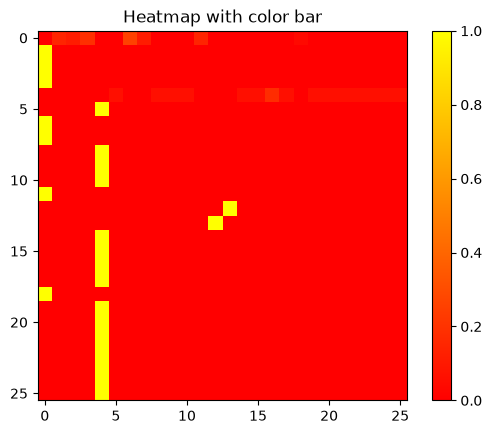

In [11]:
element_ids = ["4:f766f605-3643-4f9c-8554-440a213da53a:156", "4:f766f605-3643-4f9c-8554-440a213da53a:205", "4:f766f605-3643-4f9c-8554-440a213da53a:210", "4:f766f605-3643-4f9c-8554-440a213da53a:218", "4:f766f605-3643-4f9c-8554-440a213da53a:222", "4:f766f605-3643-4f9c-8554-440a213da53a:225", "4:f766f605-3643-4f9c-8554-440a213da53a:228", "4:f766f605-3643-4f9c-8554-440a213da53a:231", "4:f766f605-3643-4f9c-8554-440a213da53a:237", "4:f766f605-3643-4f9c-8554-440a213da53a:241", "4:f766f605-3643-4f9c-8554-440a213da53a:249", "4:f766f605-3643-4f9c-8554-440a213da53a:265", "4:f766f605-3643-4f9c-8554-440a213da53a:269", "4:f766f605-3643-4f9c-8554-440a213da53a:272", "4:f766f605-3643-4f9c-8554-440a213da53a:279", "4:f766f605-3643-4f9c-8554-440a213da53a:291", "4:f766f605-3643-4f9c-8554-440a213da53a:298", "4:f766f605-3643-4f9c-8554-440a213da53a:307", "4:f766f605-3643-4f9c-8554-440a213da53a:314", "4:f766f605-3643-4f9c-8554-440a213da53a:321", "4:f766f605-3643-4f9c-8554-440a213da53a:328", "4:f766f605-3643-4f9c-8554-440a213da53a:334", "4:f766f605-3643-4f9c-8554-440a213da53a:337", "4:f766f605-3643-4f9c-8554-440a213da53a:153", "4:f766f605-3643-4f9c-8554-440a213da53a:217", "4:f766f605-3643-4f9c-8554-440a213da53a:248"]
test = get_combinatorial_coverage(element_ids)
table = to_table(test)
for row in table:
    print(row)

show_data(table)

In [66]:
@_uses_db
def query_combinatorial_comparative_coverage(spec_id1, spec_id2, session = None):
    query = f"""CALL(){{
    match (s:SpecificationNode) where elementId(s) = "{spec_id1}"
    match (vn:ValueNode) where (vn)-[:IS_SPECIFIED_BY]->(s)
    return vn

    UNION

    match (s:SpecificationNode) where elementId(s) = "{spec_id2}"
    match (vn:ValueNode) where (vn)-[:IS_SPECIFIED_BY]->(s)
    return vn
}}
WITH vn

MATCH (root:ValueNode) WHERE NOT (root)<-[:CONTAINS]-()
MATCH (vn) WHERE (root)-[:CONTAINS*]->(vn) 
WITH collect(vn) AS coverage, root AS _
UNWIND apoc.coll.combinations(coverage, 2) as node_couple
WITH node_couple, count(node_couple) AS weight
CALL apoc.coll.elements(node_couple) YIELD _1n, _2n
match (_1n)-[:IS_SPECIFIED_BY]->(s)
return _1n, weight, _2n order by s"""
    result = session.run(query)
    ret = []
    for n1, w, n2 in result:
        ret.append((n1, w, n2))
    
    return ret

def to_table(data: dict[str, list[tuple[str, float]]]):
    data_row = [k for k in data.keys()]
    table = []

    for _, target_list in data.items():
        temp = []
        for e_id in data_row:
            for (target, weight) in target_list:
                if target == e_id:
                    temp.append(weight)
                    break
            else:
                temp.append(-1.)
        table.append(temp)

    return table

def add_element(dic: dict[str, list[tuple[str, float]]], node1, weight, node2):
    node_id = node1.element_id
    value = float(weight)/node1["occurrence"]
    if node_id in dic:
        dic[node_id].append((node2.element_id, value))
    else:
        dic[node_id] = [(node2.element_id, value)]

def get_combinatorial_comparative_coverage(spec_id1, spec_id2):
    relations = query_combinatorial_comparative_coverage(spec_id1, spec_id2)#, mapping
    
    elements = {}
    for n1, w, n2 in relations:
        add_element(elements, n1, w, n2)
    for n1, w, n2 in relations:
        add_element(elements, n2, w, n1)

    return elements

element_ids = ["4:f766f605-3643-4f9c-8554-440a213da53a:356", "4:f766f605-3643-4f9c-8554-440a213da53a:346"]
test = get_combinatorial_comparative_coverage(*element_ids)
table = to_table(test)


show_data(table)

TypeError: show_data() missing 1 required positional argument: 'meta'

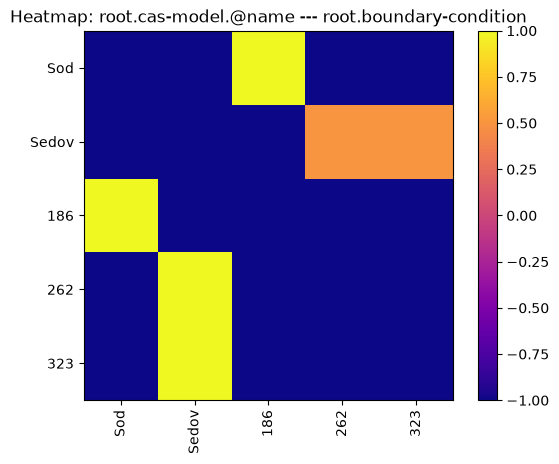

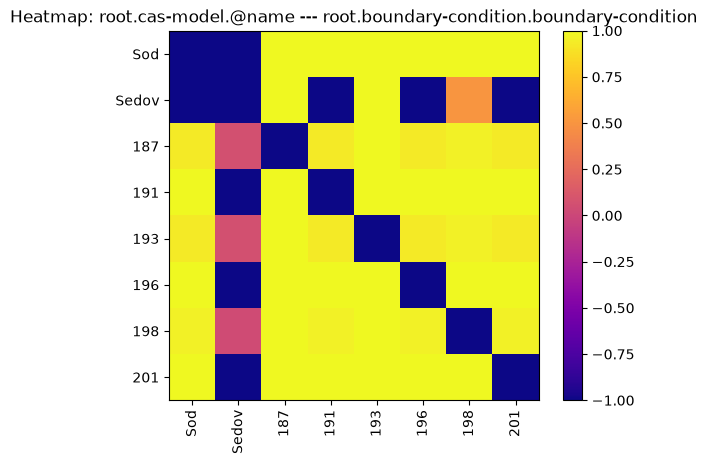

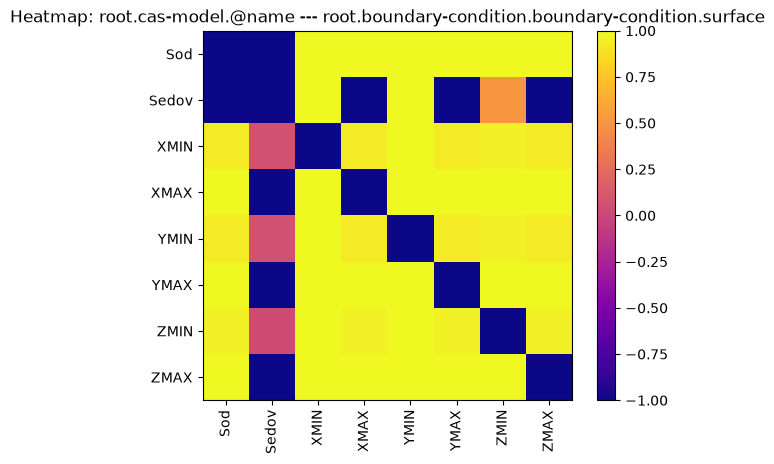

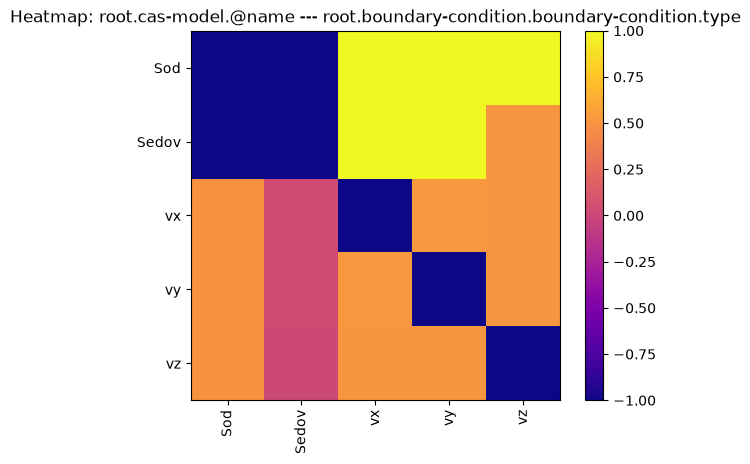

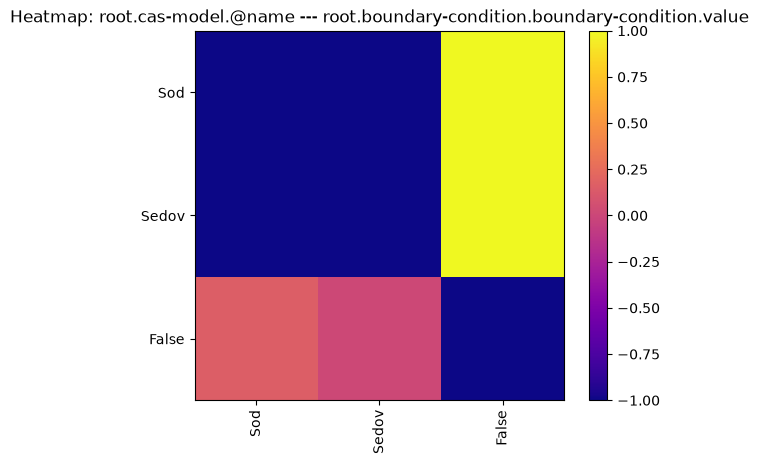

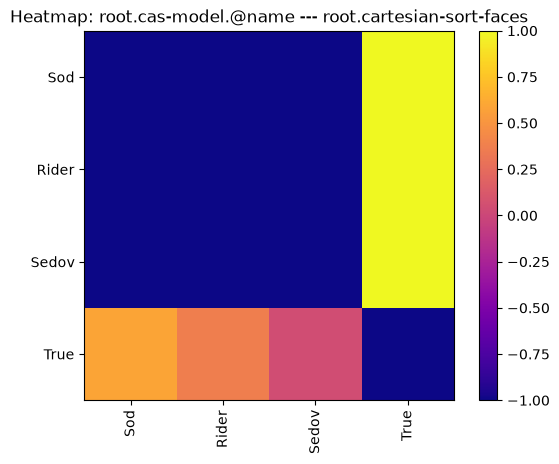

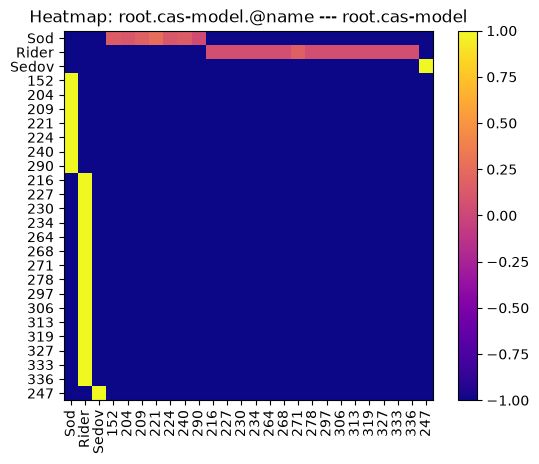

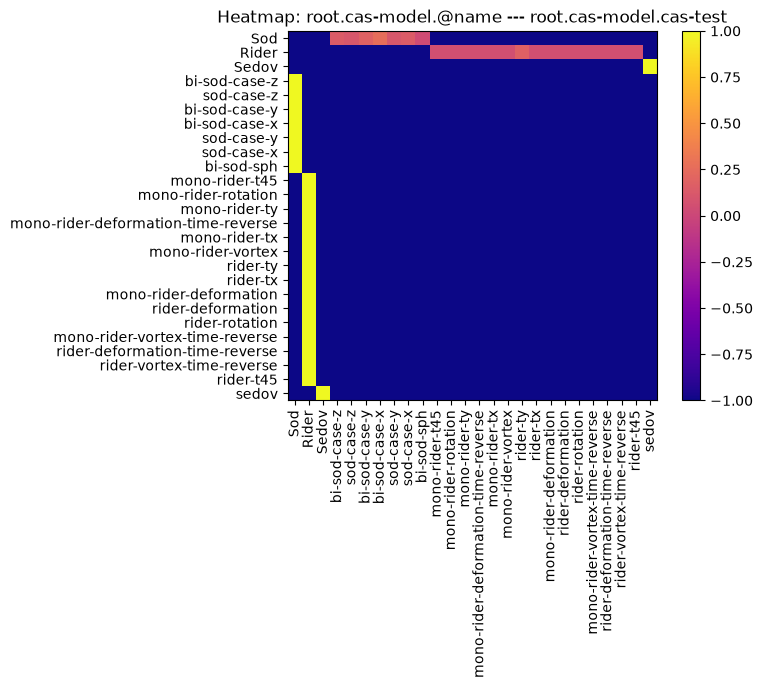

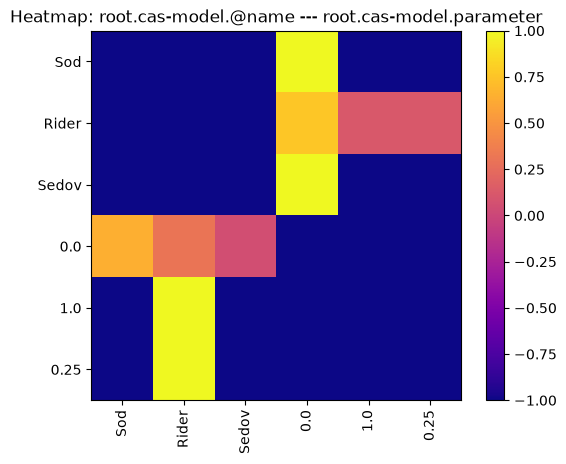

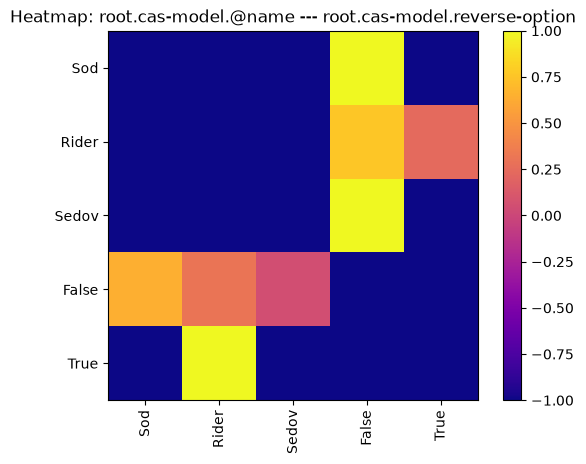

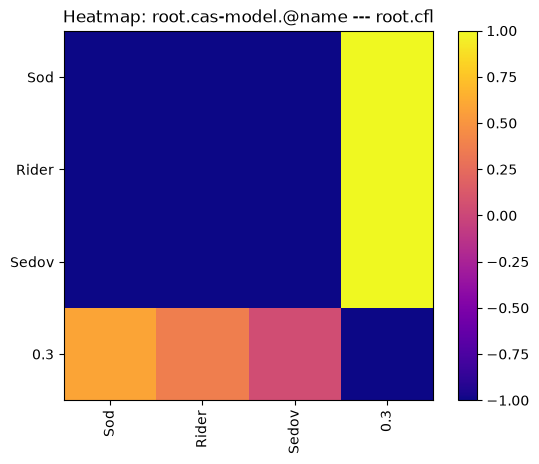

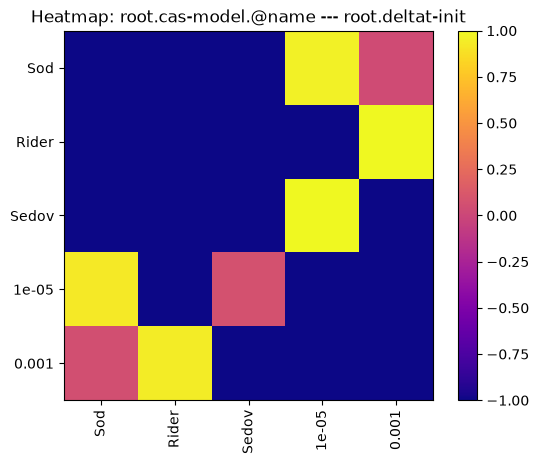

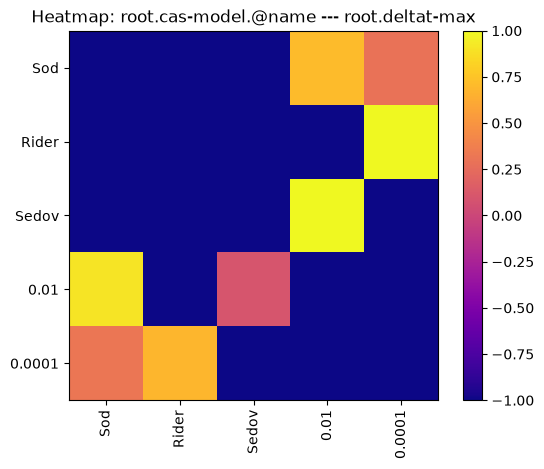

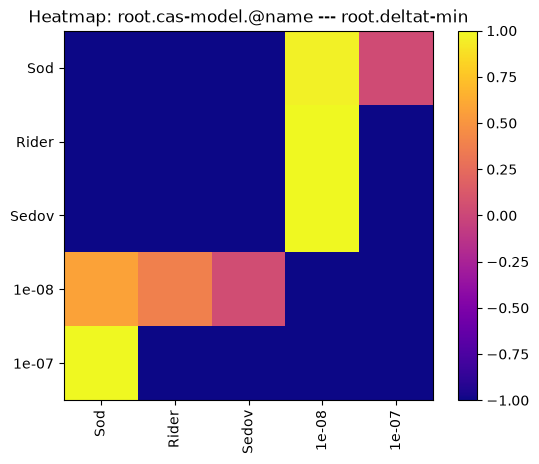

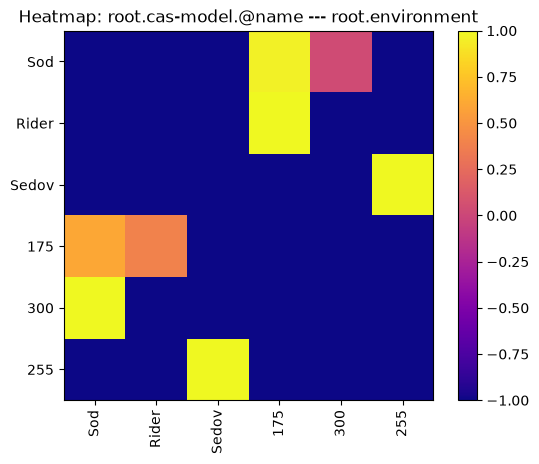

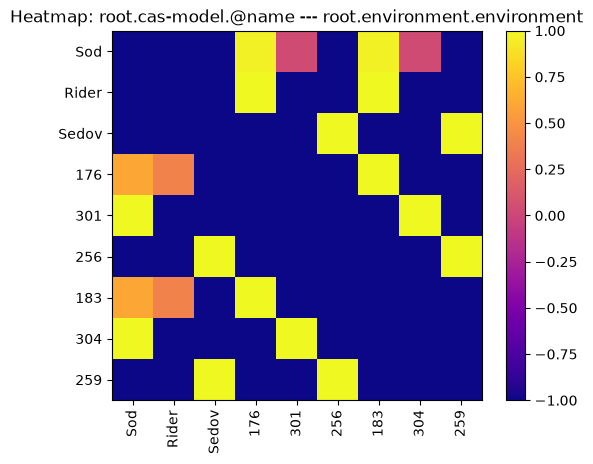

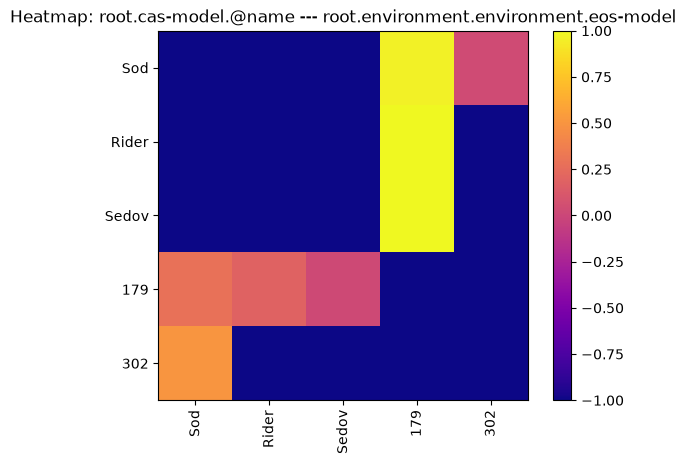

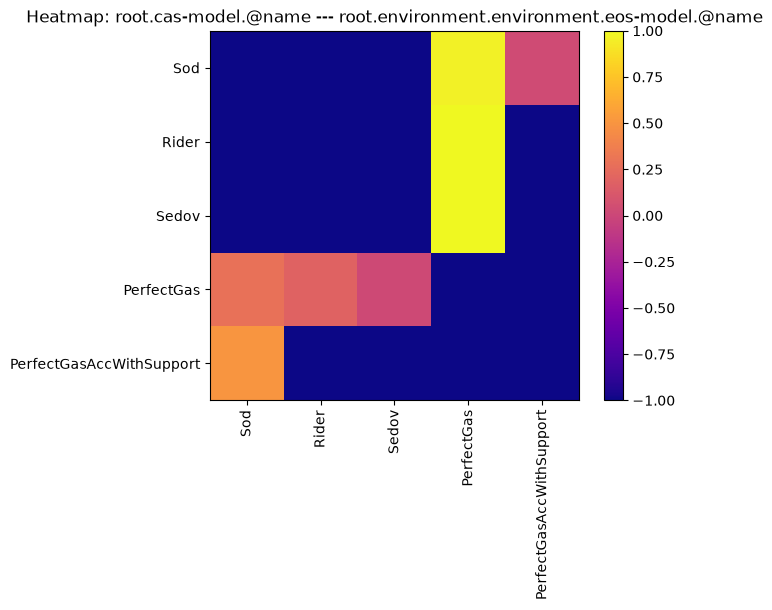

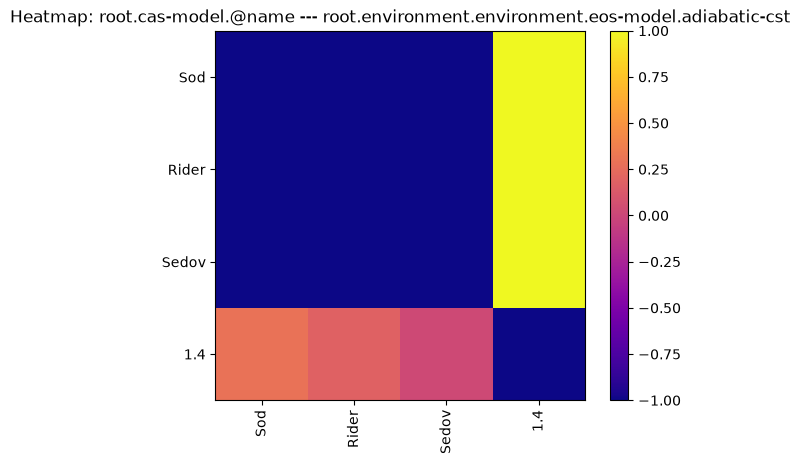

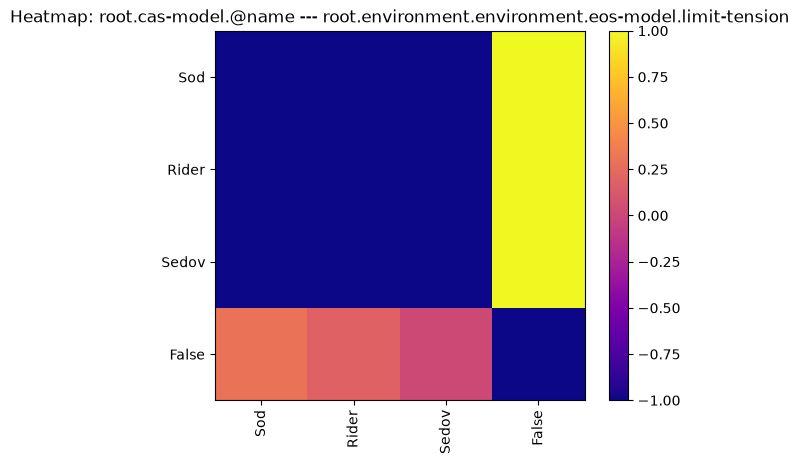

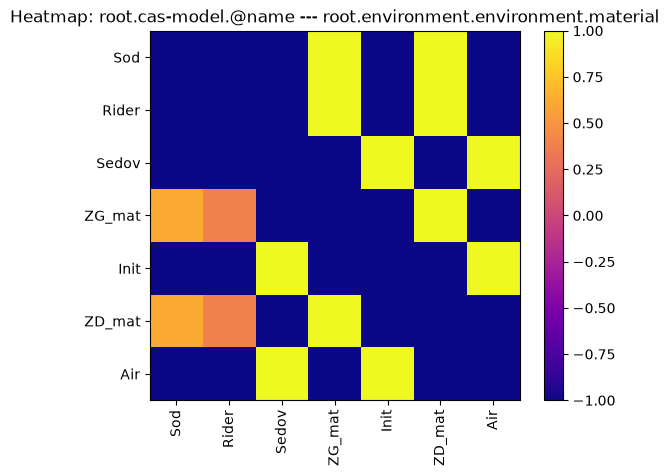

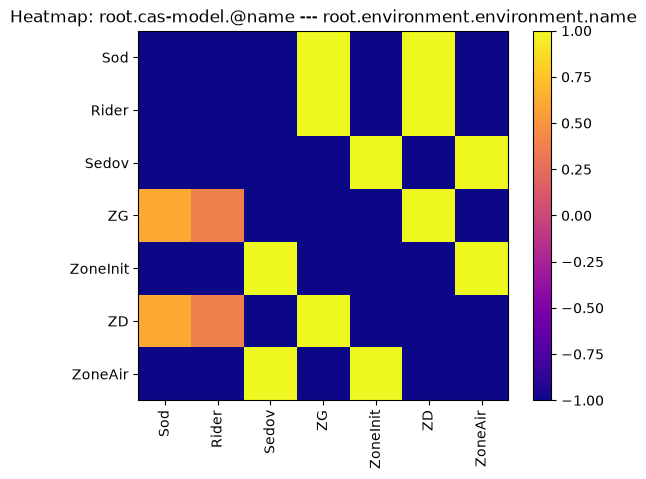

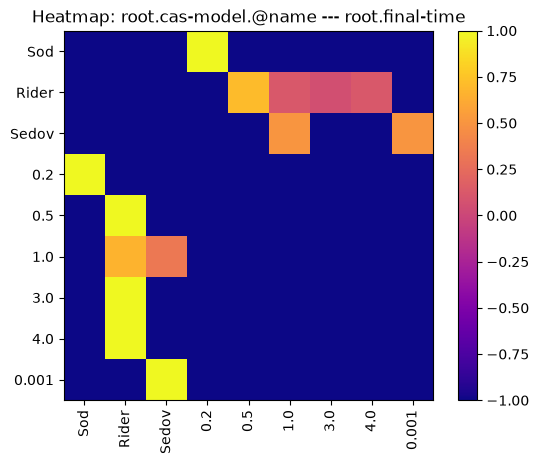

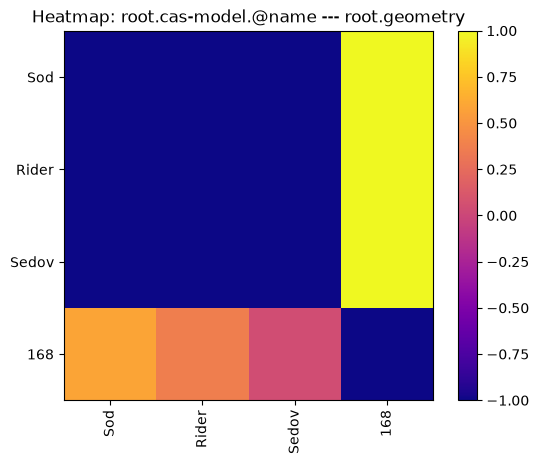

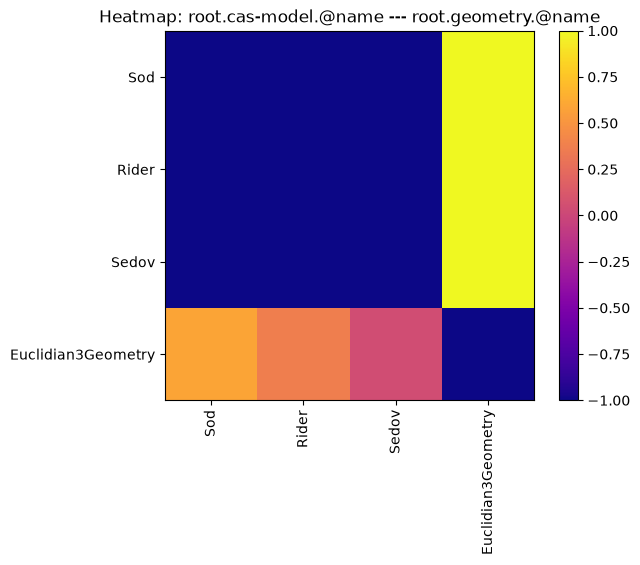

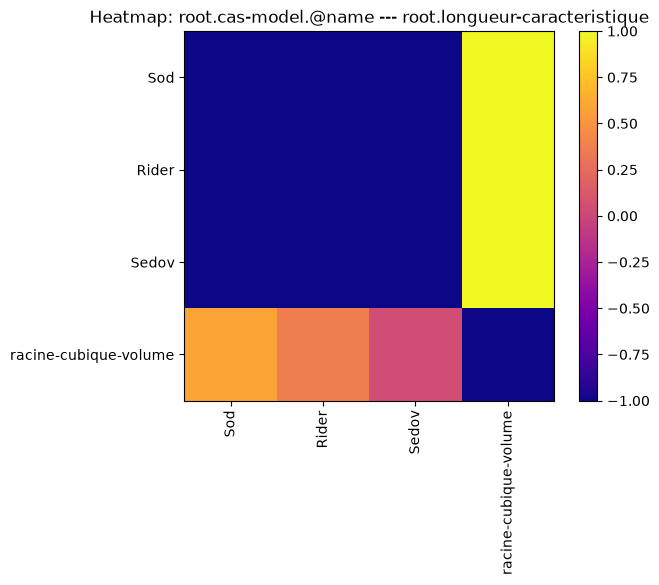

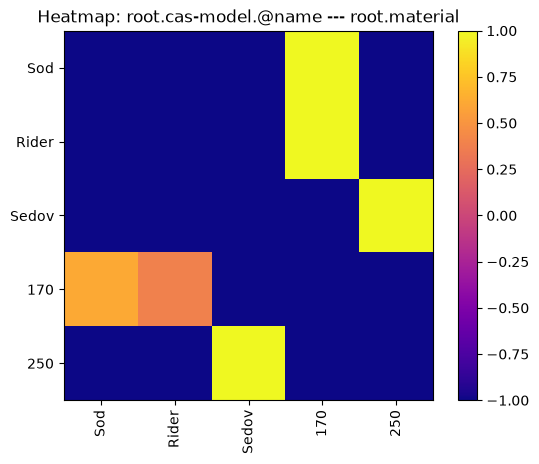

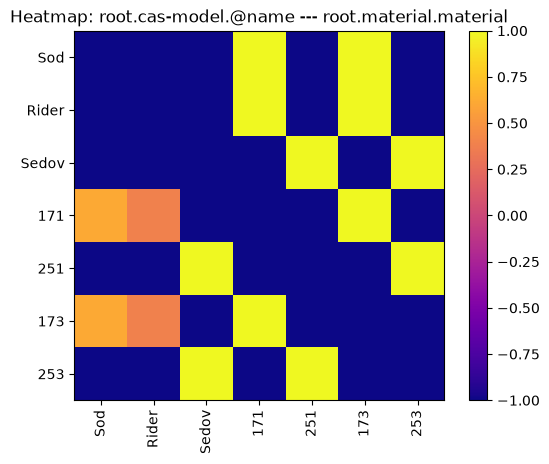

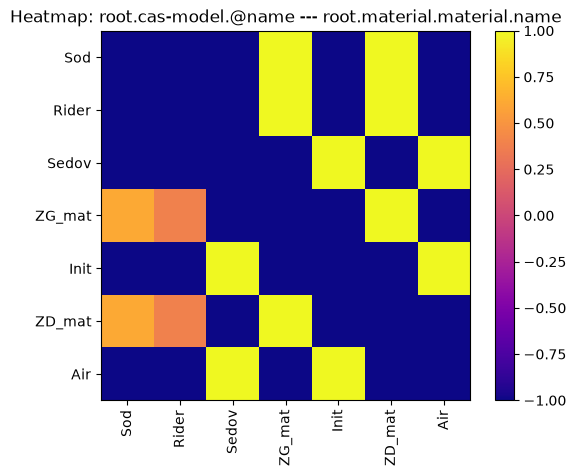

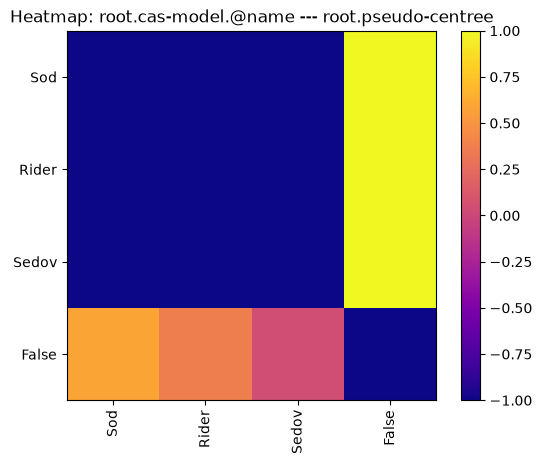

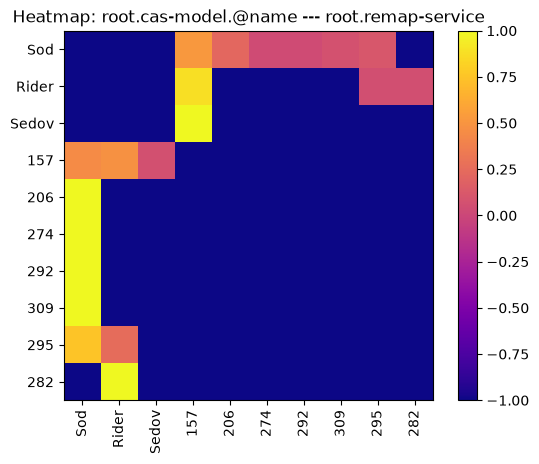

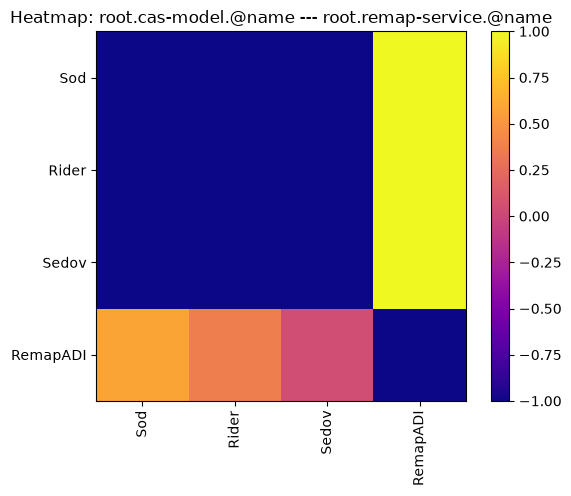

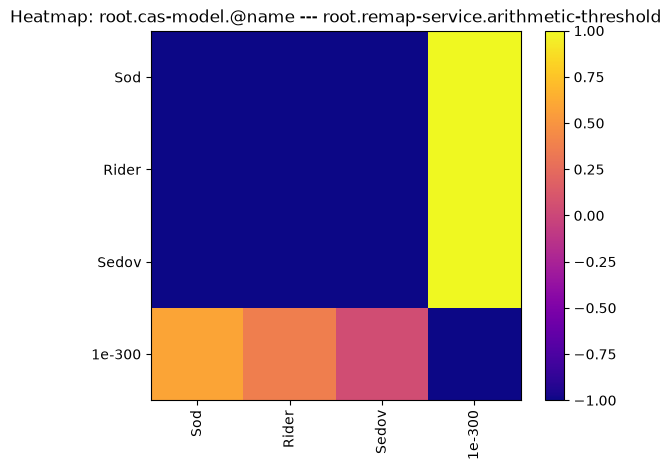

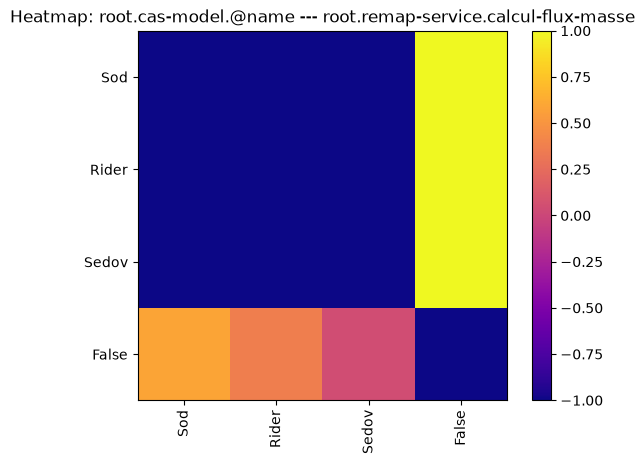

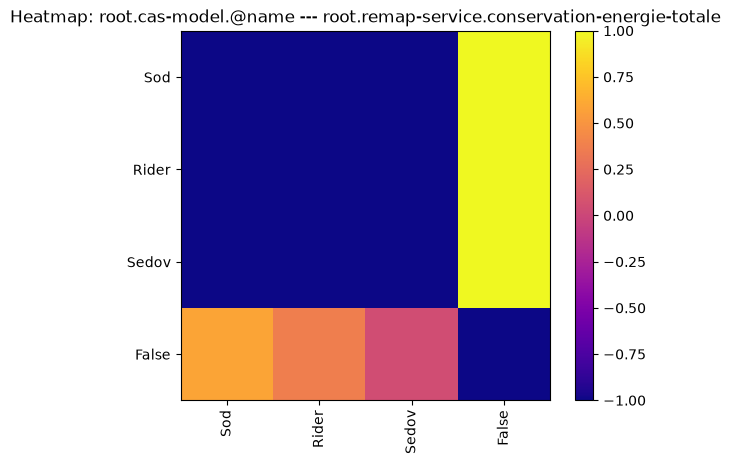

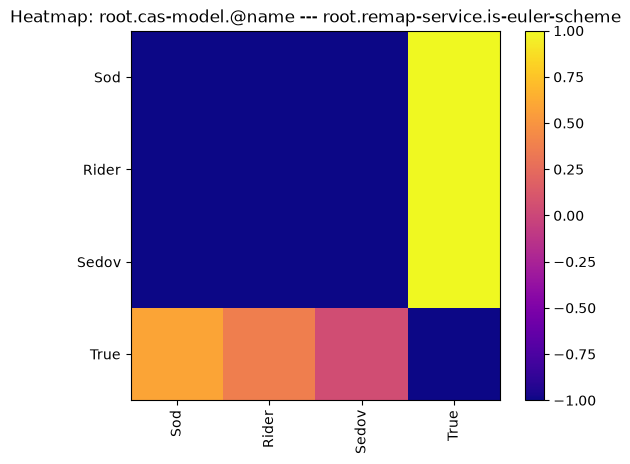

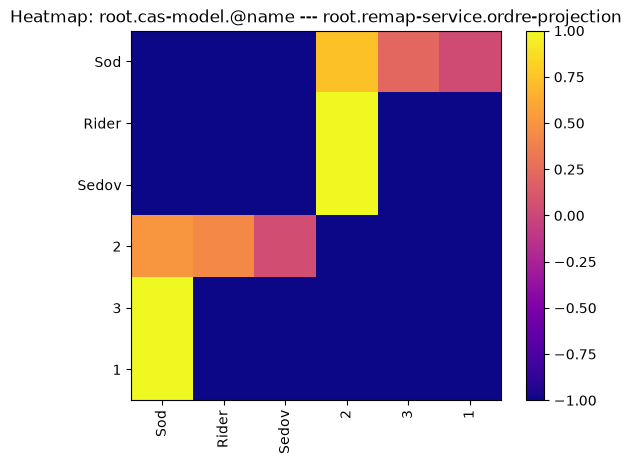

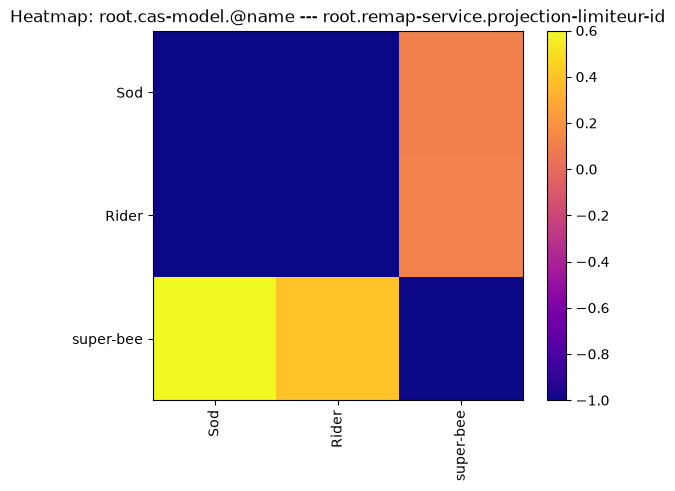

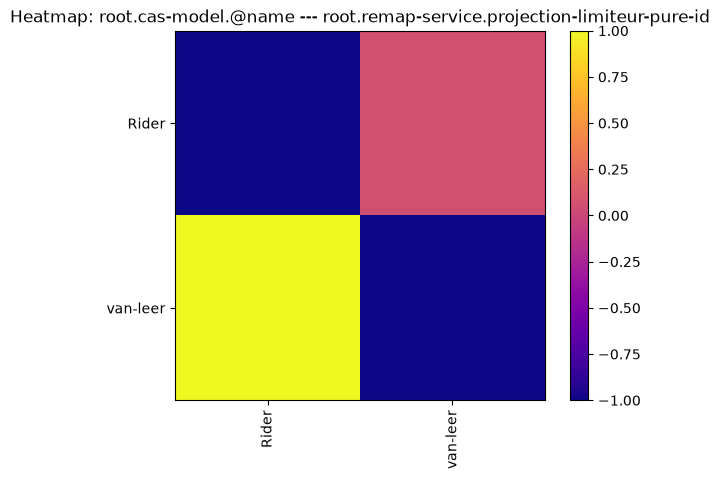

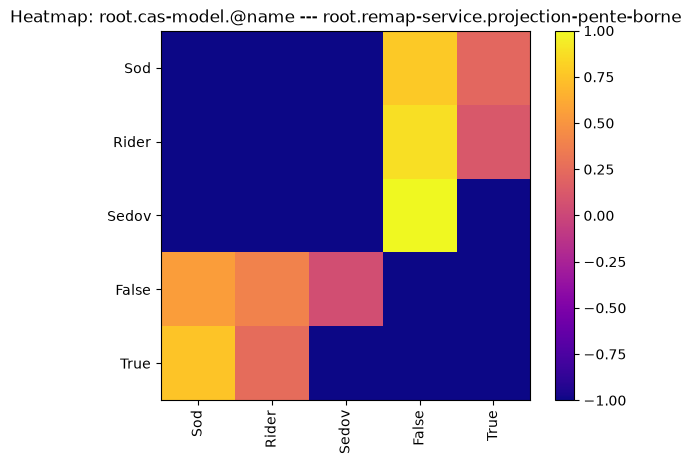

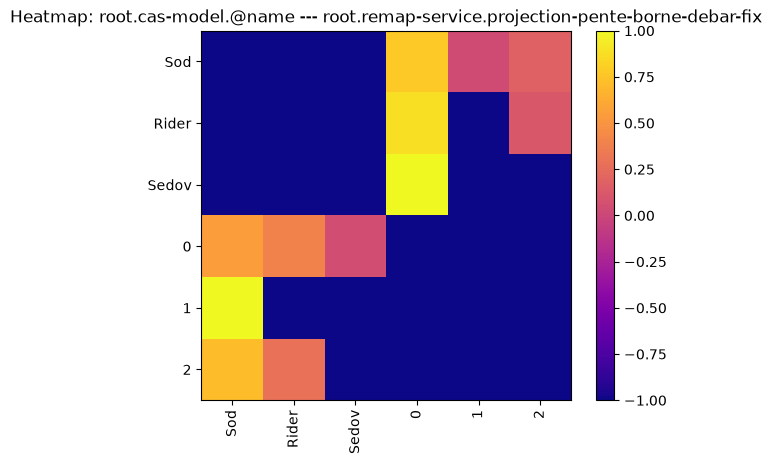

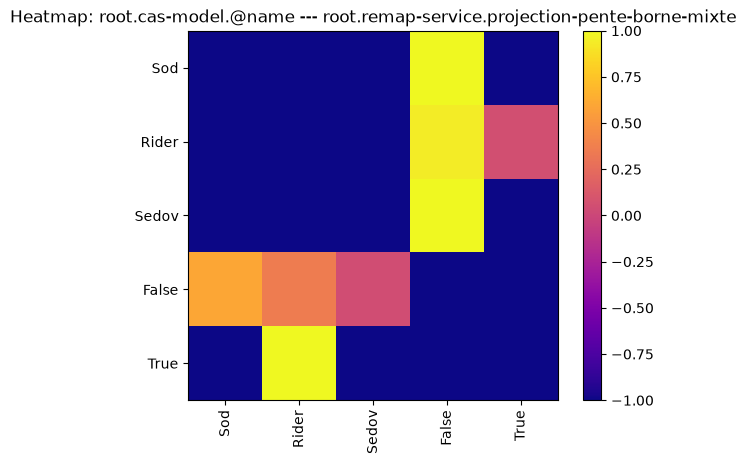

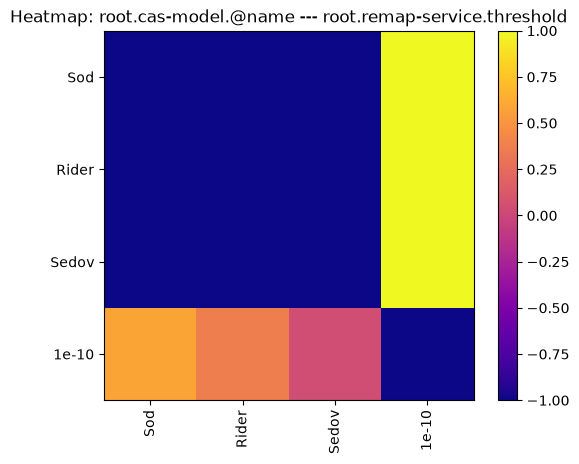

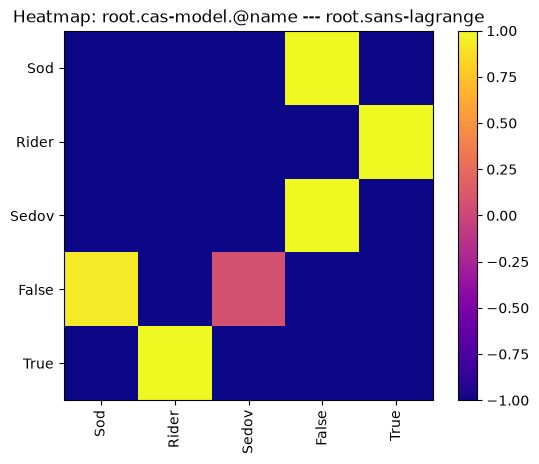

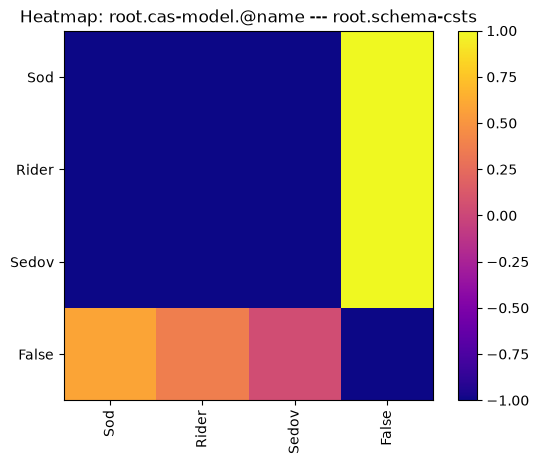

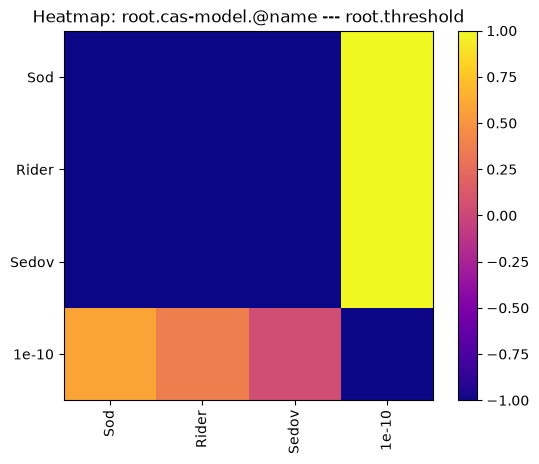

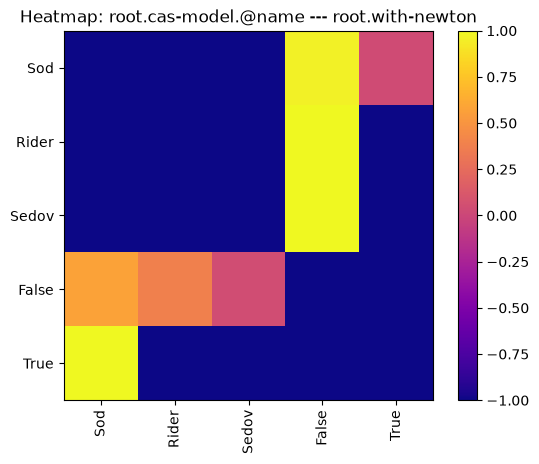

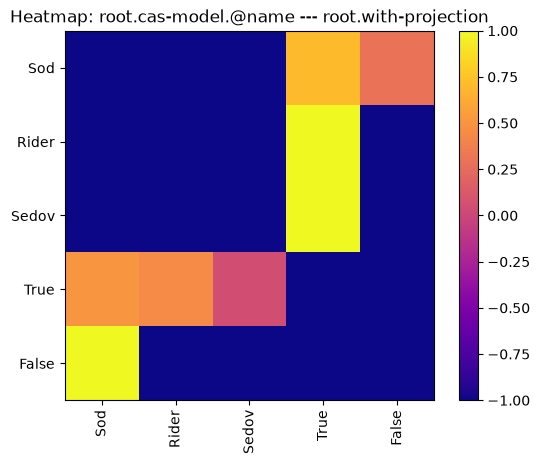

In [67]:

def show_data(data, meta):
    plt.imshow(data, cmap='plasma', interpolation='nearest')

    plt.colorbar()
    plt.title(f"Heatmap: {meta["title"]}")
    plt.xticks(range(len(meta["values_names"])), meta["values_names"], rotation = 90)
    plt.yticks(range(len(meta["values_names"])), meta["values_names"])

    plt.show()

def set_add(liste, e):
    if e in liste: return
    else: liste.append(e)

def get_combinatorial_comparative_coverage(spec_id1, spec_id2):
    relations = query_combinatorial_comparative_coverage(spec_id1, spec_id2)#, mapping
    
    elements = {}
    names = []

    for n1, w, n2 in relations:
        add_element(elements, n1, w, n2)
        set_add(names, n1["value"] if n1["value"] is not None else n1.element_id[39:])
    for n1, w, n2 in relations:
        add_element(elements, n2, w, n1)
        set_add(names, n2["value"] if n2["value"] is not None else n2.element_id[39:])

    return elements, names


def to_table(data: dict[str, list[tuple[str, float]]]):
    data_row = [k for k in data.keys()]
    table = []

    for _, target_list in data.items():
        temp = []
        for e_id in data_row:
            for (target, weight) in target_list:
                if target == e_id:
                    temp.append(weight)
                    break
            else:
                temp.append(-1.)
        table.append(temp)

    return table


base_node, base_path = "4:f766f605-3643-4f9c-8554-440a213da53a:356", "root.cas-model.@name"
specs = query_all_specs()

for n in specs:
    if n["id"] == base_node: continue
    coc, names = get_combinatorial_comparative_coverage(base_node, n["id"])
    if coc == {}: continue
    
    table = to_table(coc)
    metadata = {"title": f"{base_path} --- {n["path"]}", "values_names": names}
    show_data(table, metadata)